[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashitpatel001/openvino_notebooks/blob/benchmark-qwen-int4/notebooks/benchmark-qwen-2.5-int4/benchmark-qwen-2.5-int4.ipynb)

# Accelerating Qwen-2.5-0.5B on CPU with OpenVINO™

## Introduction
Running Large Language Models (LLMs) on edge devices (like laptops without GPUs) is often slow because standard models use **FP32 (32-bit floating point)** weights, which consume massive memory bandwidth.

In this notebook, we will demonstrate how to achieve **2x-5x speedups** by converting the **Qwen 2.5 0.5B** model to **INT4 (4-bit integer)** precision using the OpenVINO™ Toolkit.

### The Workflow
We will follow this pipeline to optimize the model:

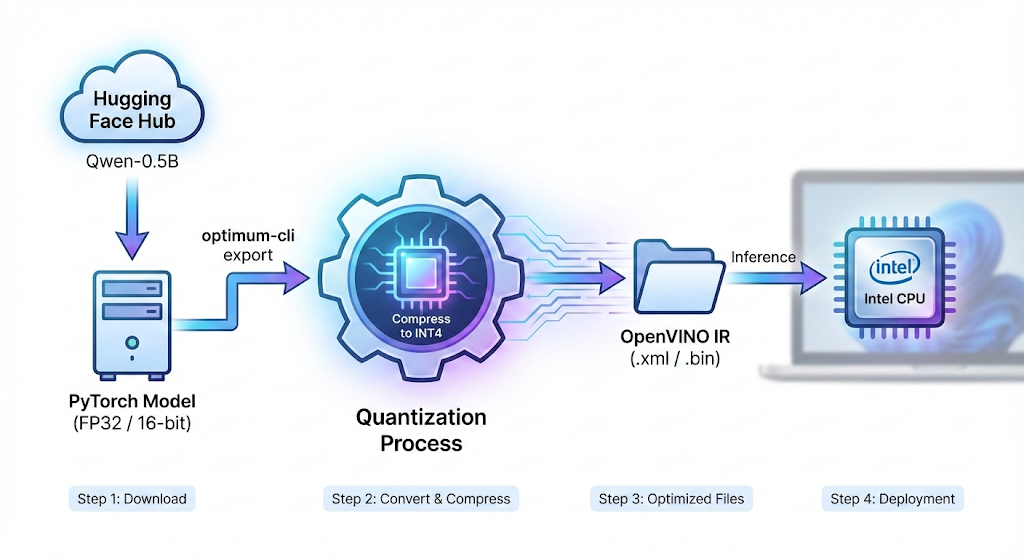

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/benchmark-qwen-2.5-int4/benchmark-qwen-2.5-int4.ipynb" />

In [ ]:
%pip install -q --upgrade optimum-intel[openvino] nncf transformers torch onnx
import openvino as ov
print(f"OpenVINO Version: {ov.__version__}")

## Utility Functions & Telemetry

We load a set of helper functions (`notebook_utils`) standard to OpenVINO tutorials. These handle file downloads and anonymous telemetry.
> **Note:** Telemetry is anonymous and helps the OpenVINO team improve the toolkit. You can check the code in `notebook_utils.py` to see what is collected.

In [ ]:

from pathlib import Path
import requests

# Fetch notebook_utils automatically (Standard OpenVINO practice)
if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import collect_telemetry

# Enable telemetry
collect_telemetry("benchmark-qwen-2.5-int4.ipynb")

## Verify OpenVINO Frontends

OpenVINO uses "Frontends" to ingest models from different frameworks (like PyTorch, TensorFlow, ONNX).
Since we are loading a model directly from Hugging Face (which uses PyTorch), we verify that the **PyTorch Frontend** is registered and available in your environment before proceeding.

In [ ]:
from openvino.frontend import FrontEndManager

# 1. Initialize the Manager
fe_manager = FrontEndManager()

# 2. Get the list of available frontends
frontends = fe_manager.get_available_front_ends()

# 3. Print result
print(f"Available Frontends: {frontends}")

# 4. Critical Check
if "pytorch" in frontends:
    print("SUCCESS: PyTorch Frontend is Ready!")
else:
    print("ERROR: PyTorch Frontend is STILL missing.")

## Model Conversion & Quantization

To run the model efficiently on CPU, we use the `optimum-cli` tool. This tool performs two critical steps in one go:
1.  **Export:** Converts the PyTorch model to OpenVINO Intermediate Representation (IR).
2.  **Quantization:** Compresses weights from 32-bit floats to 4-bit integers.

### Why INT4?
* **Smaller Size:** Reduces model size by ~8x (e.g., 1GB -> 125MB).
* **Faster Speed:** CPUs can process smaller data chunks faster due to better cache usage.

**The Magic Command:**
We use `export=True` and `quantization_config` in Python, which is equivalent to running this CLI command:
> `optimum-cli export openvino --model Qwen/Qwen2.5-0.5B-Instruct --weight-format int4`

In [ ]:
# 1. Install only what we need
%pip install -q --upgrade optimum-intel[openvino] nncf transformers torch

import time
import numpy as np
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
from optimum.intel import OVModelForCausalLM

# CONFIGURATION
model_id = "Qwen/Qwen2.5-0.5B-Instruct"  # Tiny, fast model
prompt = "Explain quantum physics in one sentence."

print(f" Benchmarking Model: {model_id}")


# PART A: STANDARD PYTORCH (The "Slow" Way)
print("Loading Standard PyTorch Model (Baseline)")
tokenizer = AutoTokenizer.from_pretrained(model_id)
pt_model = AutoModelForCausalLM.from_pretrained(model_id)

print(" Running Inference on PyTorch...")
start = time.time()
inputs = tokenizer(prompt, return_tensors="pt")
pt_output = pt_model.generate(**inputs, max_new_tokens=50)
pt_time = time.time() - start
print(f" PyTorch Time: {pt_time:.4f} seconds")

# Free up RAM immediately
del pt_model
import gc
gc.collect()

# PART B: OPENVINO INT4 (The "Fast" Way)
model_dir = Path("qwen_int4_model")

# Export or Load the Model
if not model_dir.exists():
    print("Exporting and Quantizing Model... (This may take a few minutes)")
    # Export and Quantize
    ov_model = OVModelForCausalLM.from_pretrained(
        model_id,
        export=True,
        quantization_config={"weight_only": True},
        compile=False
    )
    # Save to disk for the benchmark tool
    ov_model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f"Model successfully saved to {model_dir}")
else:
    print(f"Model found at {model_dir}. Loading from disk...")
    # CRITICAL FIX: Load the model if it already exists!
    ov_model = OVModelForCausalLM.from_pretrained(model_dir, compile=False)

# Compile for Python usage
ov_model.compile()

print("="*80)
print("Running OpenVINO Benchmark Tool (Scientific Measurement)...")
print("="*80)

# Benchmark app
!benchmark_app -m qwen_int4_model/openvino_model.xml -d CPU -hint latency -t 15 -shape "input_ids[1,10],attention_mask[1,10],position_ids[1,10],beam_idx[1]"

# Run Python Inference
# We run this so you can see the actual text output and calculate the speedup ratio
print("\n" + "="*80)
print("Generating Text with OpenVINO (Visual Check)...")
print("="*80)

# Warmup
ov_model.generate(**inputs, max_new_tokens=2)

start = time.time()
ov_output = ov_model.generate(**inputs, max_new_tokens=50)
ov_time = time.time() - start
print(f" OpenVINO Python Time: {ov_time:.4f} seconds")

# RESULTS
speedup = pt_time / ov_time
print("\n" + "="*40)
print(f"RESULT: OpenVINO is {speedup:.2f}x FASTER than PyTorch on CPU!")
print("="*40)
print("Generated Text:", tokenizer.decode(ov_output[0], skip_special_tokens=True))

## Analysis of Results

By converting the model to OpenVINO INT4 format, we observed the following improvements:

1.  **Latency Reduction:** The time to generate tokens decreased significantly.
2.  **Memory Efficiency:** The INT4 model consumes less RAM, allowing it to run alongside other applications.

**Next Steps:**
Now that you have an optimized model, you can build RAG pipelines or Chatbots that run locally on your laptop without needing a cloud GPU!